In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, average_precision_score, PrecisionRecallDisplay, precision_recall_curve
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
from sklearn.preprocessing import KBinsDiscretizer

## Load data

In [12]:
df1 = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df1.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


In [14]:
df = df1.copy()
child_weight_descretized = df1[['child_weight']]  # descretized child weight

# Initialize the discretizer
kbd = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform', subsample=None)  

# Fit and transform
child_weight_binned = kbd.fit_transform(child_weight_descretized)

# Add back to DataFrame
df['child_weight_binned'] = child_weight_binned.astype(int)
df = df.drop(columns=['child_weight'])
df.head(2)

,child_age,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0,child_weight_binned
0,1,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0,0
1,3,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0,1


In [15]:
X = df.drop(columns=['malnurished'])
y = df['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [16]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 2828, 1: 2316})
After SMOTE:  Counter({1: 2828, 0: 2828})


# Naive Bayes Classifier

## Multinomial Naive Bayes

Which is for all discretized variables

### Simple model

In [17]:
model = MultinomialNB()
model.fit(X_train_sm, y_train_sm)

MultinomialNB()

In [18]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.57      0.61       707
           1       0.55      0.63      0.59       579

    accuracy                           0.60      1286
   macro avg       0.60      0.60      0.60      1286
weighted avg       0.61      0.60      0.60      1286



### Average Precision Score

In [21]:
y_probas = model.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.5892308190579156


### Hyperparameter Tuning

In [19]:
params = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0]
}

nb_params = MultinomialNB()

# Grid Search
grid_search = GridSearchCV(
    estimator=nb_params,
    param_grid=params,
    scoring='recall', 
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit the model
grid_search.fit(X_train_sm, y_train_sm)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=5, estimator=MultinomialNB(), n_jobs=-1,
             param_grid={'alpha': [0.001, 0.01, 0.1, 0.5, 1.0]},
             scoring='recall', verbose=1)

In [22]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'alpha': 0.001}
Best Cross-Validation Accuracy: 0.6159736076800401


In [20]:
nb_tune = grid_search.best_estimator_
y_pred = nb_tune.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.57      0.61       707
           1       0.55      0.63      0.59       579

    accuracy                           0.60      1286
   macro avg       0.60      0.60      0.60      1286
weighted avg       0.61      0.60      0.60      1286



### Average precision

In [24]:
y_probas_tune = nb_tune.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas_tune)}')

Average Precision: 0.5892300359367746


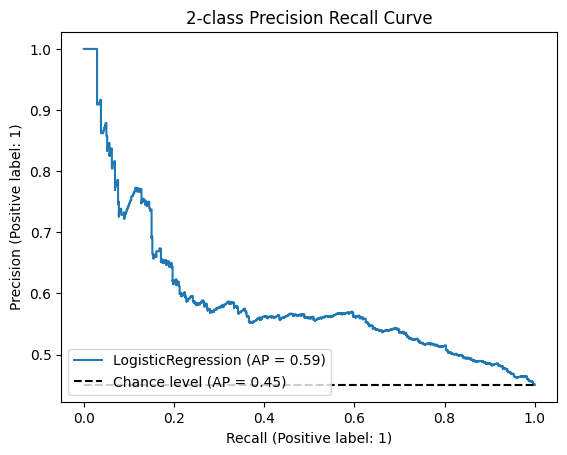

In [25]:
display = PrecisionRecallDisplay.from_estimator(
    nb_tune,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

### Confusion matrix

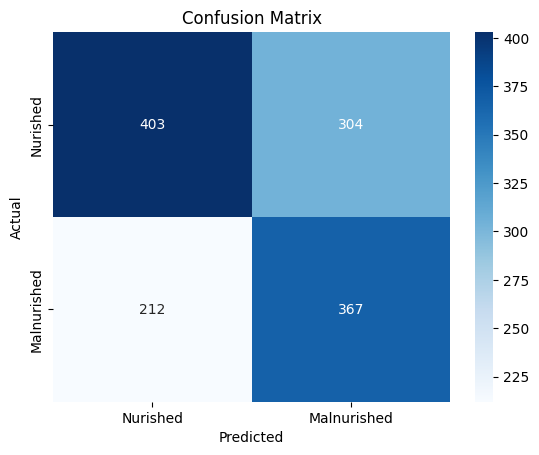

In [26]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Additional

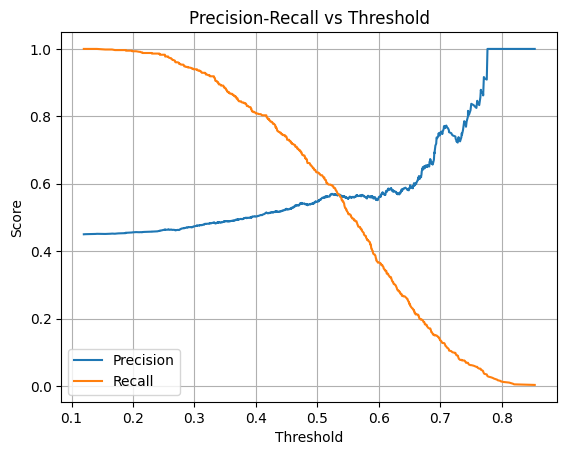

In [27]:
y_probas = nb_tune.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [28]:
# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.69      0.35      0.46       707
           1       0.50      0.81      0.62       579

    accuracy                           0.55      1286
   macro avg       0.60      0.58      0.54      1286
weighted avg       0.60      0.55      0.53      1286


